#Import Library & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/DS102/Dataset/Credit Risk Dataset.xlsx')
df.head()

Mounted at /content/drive


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


# 1 Basic Info

In [2]:
df.shape

(32581, 29)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

# 2 Missing Value

In [4]:
print(df.isnull().sum())

client_ID                        0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies  

In [18]:
duplicates = df[df.duplicated()]
if not duplicates.empty:
    print("Duplicated rows found:")
    print(duplicates)
else:
    print("No duplicated rows found.")

No duplicated rows found.


                   missing   percent
loan_int_rate         3116  9.563856
person_emp_length      895  2.747000


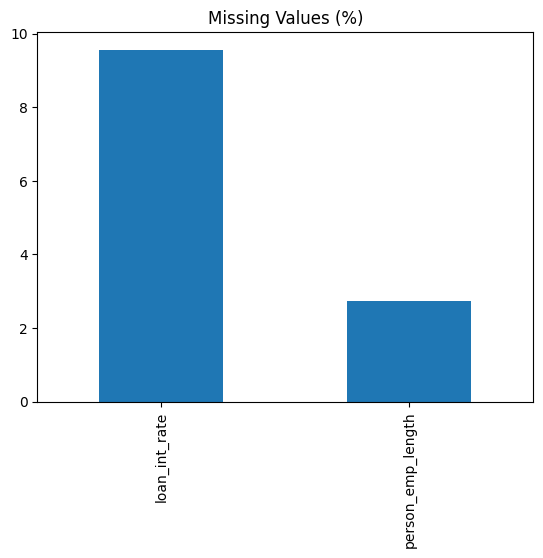

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"missing": missing, "percent": missing_pct})
print(missing_df[missing_df["missing"] > 0])

# Visualization
plt.figure()
missing_df[missing_df["missing"] > 0]["percent"].plot(kind="bar")
plt.title("Missing Values (%)")
plt.show()

# 3 Numerical Features Analysis

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,45.407613,-63.805473,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,7.644809,46.615580,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000


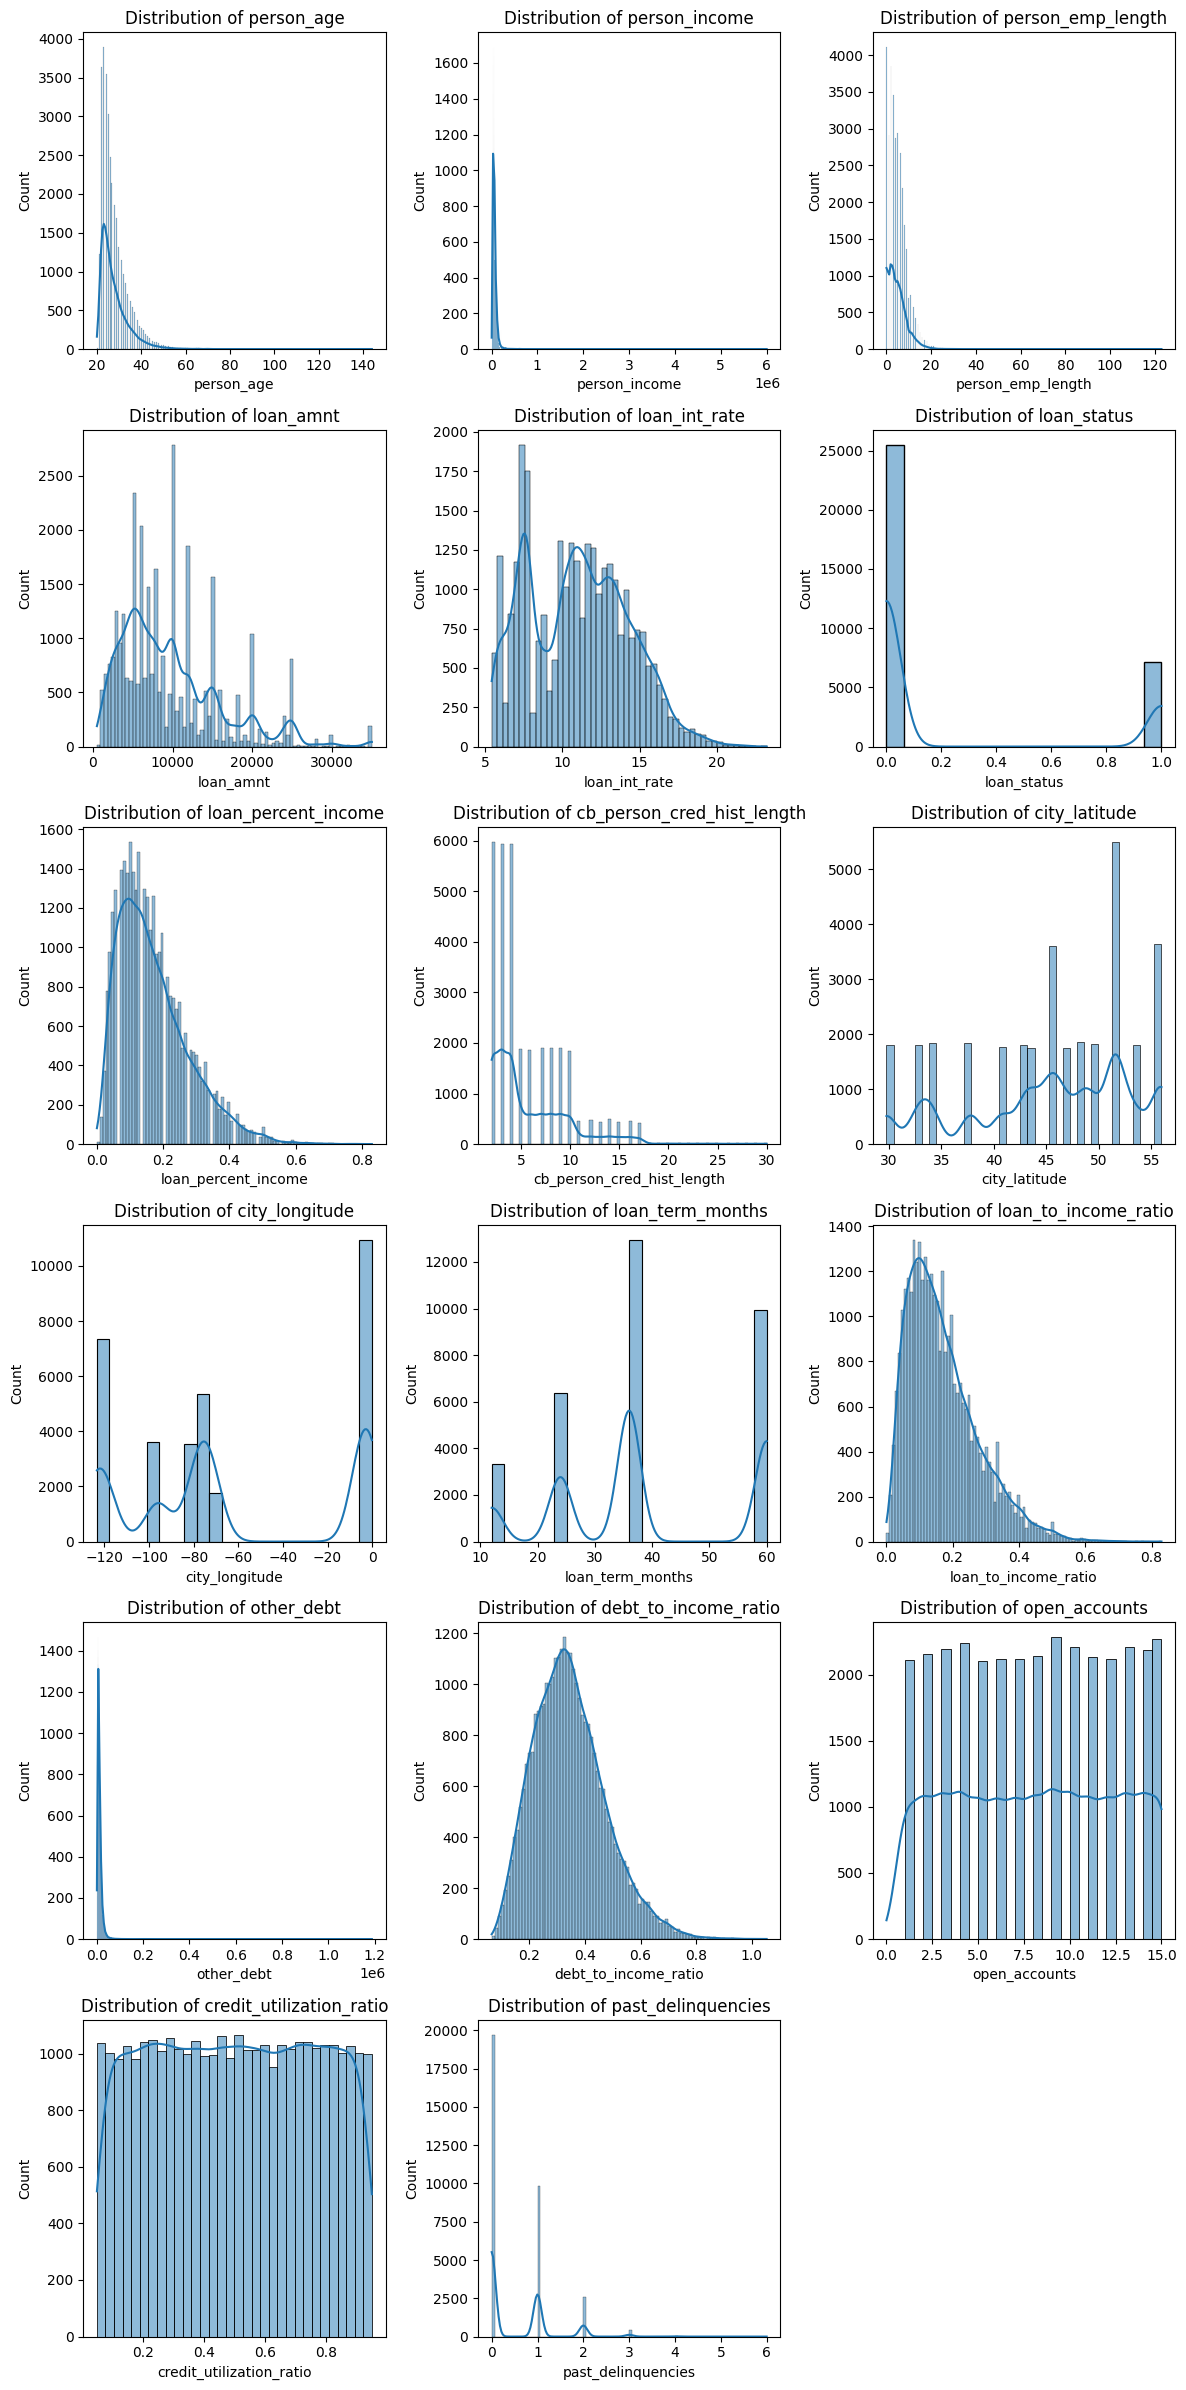

In [8]:
n_cols_grid = 3

# Tự động tính số hàng cần thiết
n_rows_grid = math.ceil(len(num_cols) / n_cols_grid)

# Khởi tạo figure và các axes
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(12, 4 * n_rows_grid))

# Dàn phẳng mảng axes ra thành 1 chiều (1D) để dễ lặp bằng vòng for
axes = axes.flatten()

# Lặp qua từng cột để vẽ
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Quan trọng: Ẩn đi các khung hình (axes) bị dư nếu số lượng num_cols bị lẻ
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để chữ không đè lên nhau
plt.tight_layout()
plt.show()

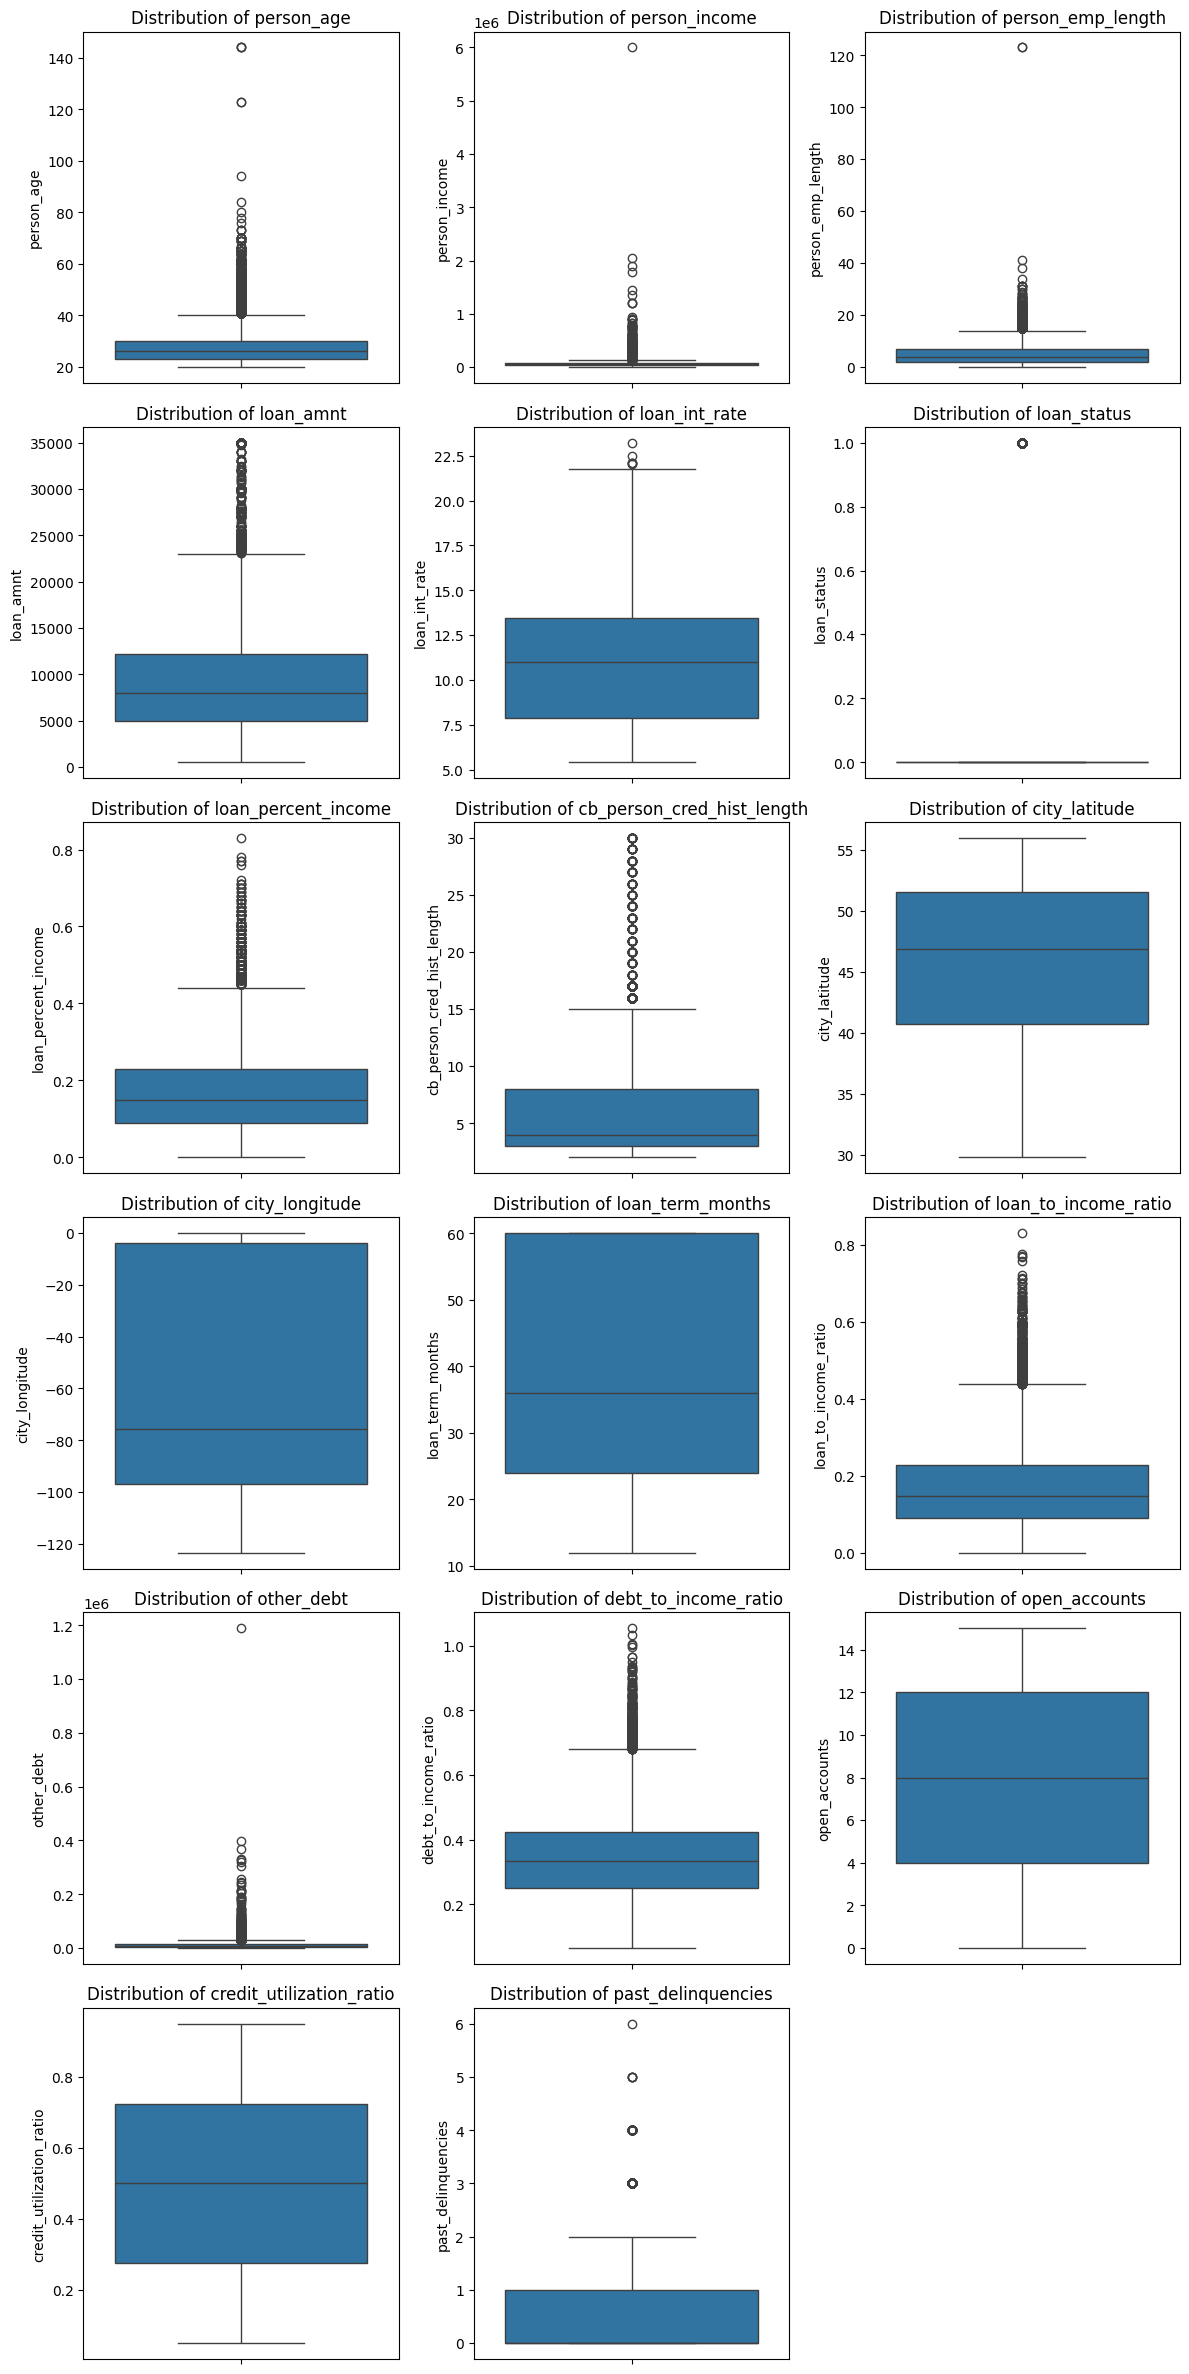

In [9]:
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(12, 4 * n_rows_grid))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(df[col].dropna(), ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4 Outlier Detection (IQR)

In [10]:
outlier_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_report, orient='index', columns=['outlier_count'])
print(outlier_df.sort_values(by='outlier_count', ascending=False))

                            outlier_count
loan_status                          7108
loan_amnt                            1689
other_debt                           1559
person_age                           1494
person_income                        1484
cb_person_cred_hist_length           1142
person_emp_length                     853
loan_to_income_ratio                  733
loan_percent_income                   651
past_delinquencies                    464
debt_to_income_ratio                  463
loan_int_rate                           6
city_latitude                           0
city_longitude                          0
loan_term_months                        0
open_accounts                           0
credit_utilization_ratio                0


# 5 Categorical Features

In [11]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols = cat_cols.drop('client_ID')

print("\n===== CATEGORICAL SUMMARY =====")

for col in cat_cols:
    print(f'{df[col].value_counts()}\n')


===== CATEGORICAL SUMMARY =====
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

gender
Male      16371
Female    16210
Name: count, dtype: int64

marital_status
Single      16368
Married     11393
Divorced     3173
Widowed      1647
Name: count, dtype: int64

education_level
High School    13185
Bachelor       11390
Master          6508
PhD             1498
Name: count, dtype: int64

country
UK        10944
USA       10852
Canada    10785
Name: count, dtype: int64

state
BC            3679
California    3679
England       3654
Scotland

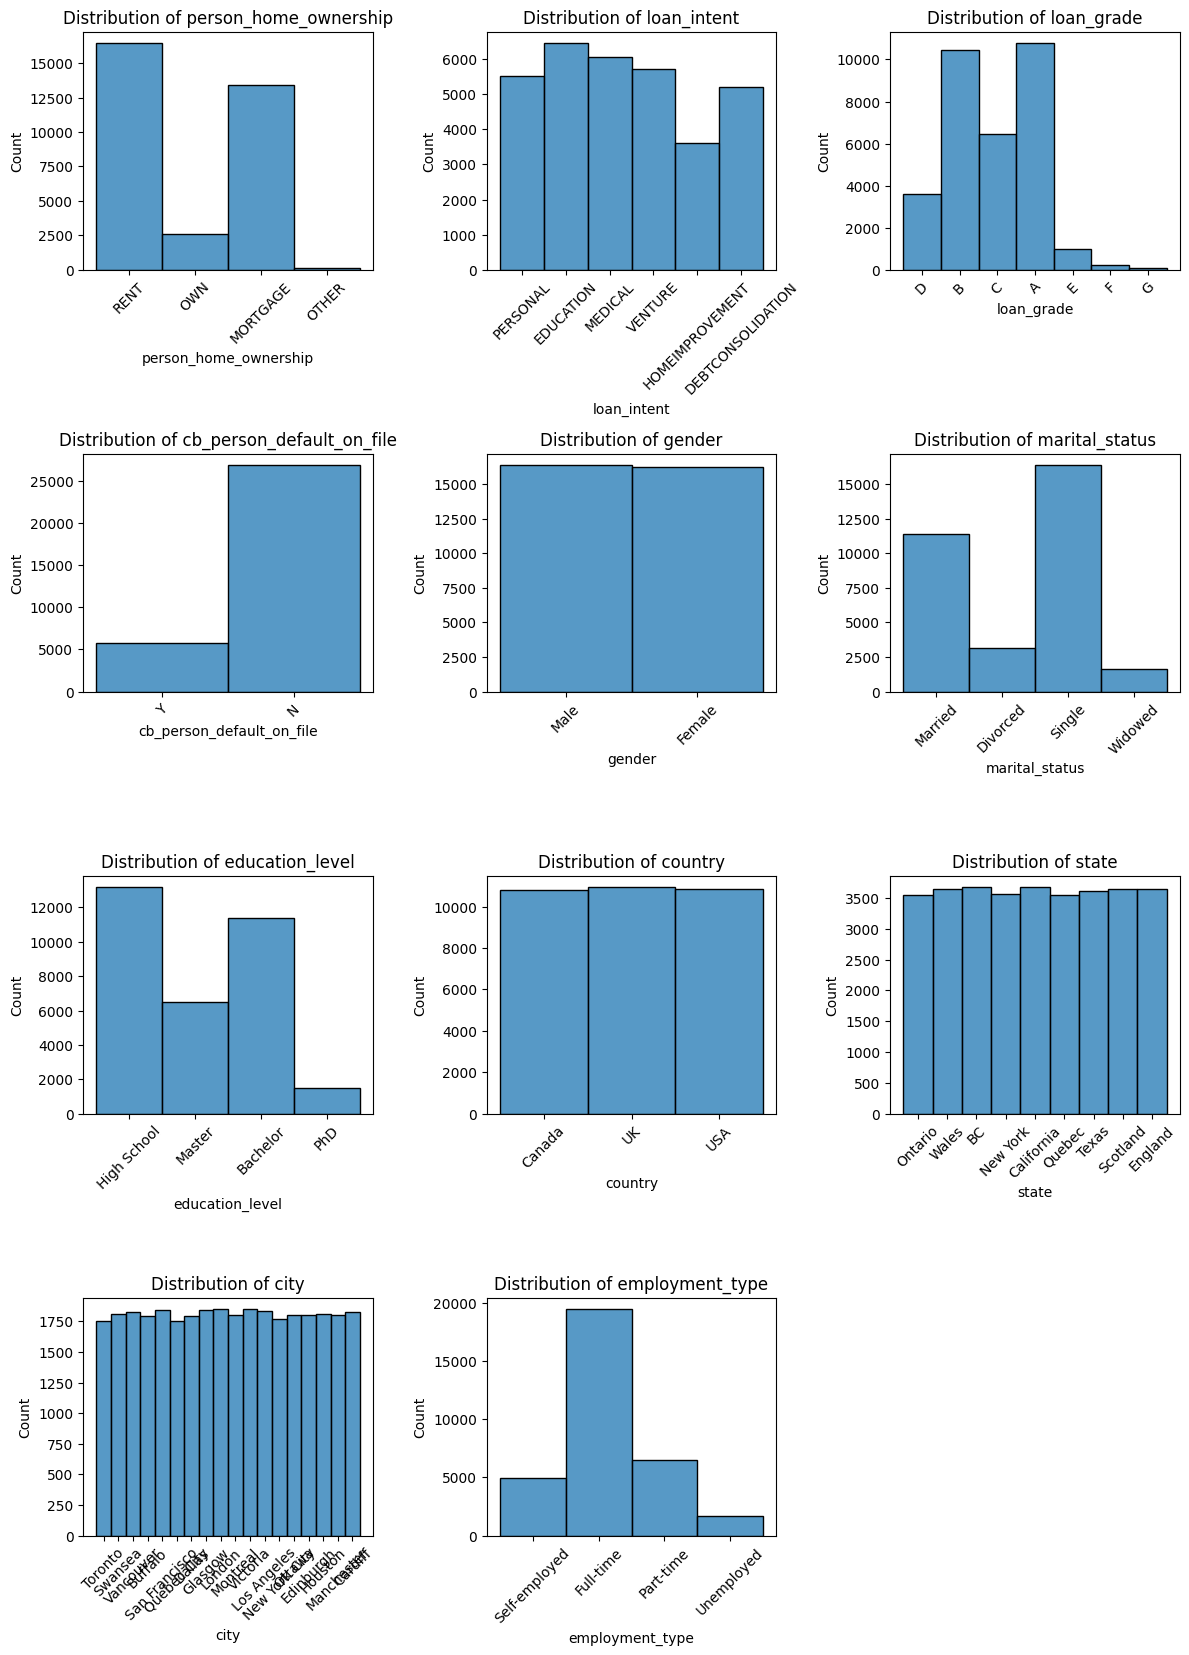

In [12]:
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(12, 4 * n_rows_grid))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', labelrotation=45)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 6 Correlation analysis

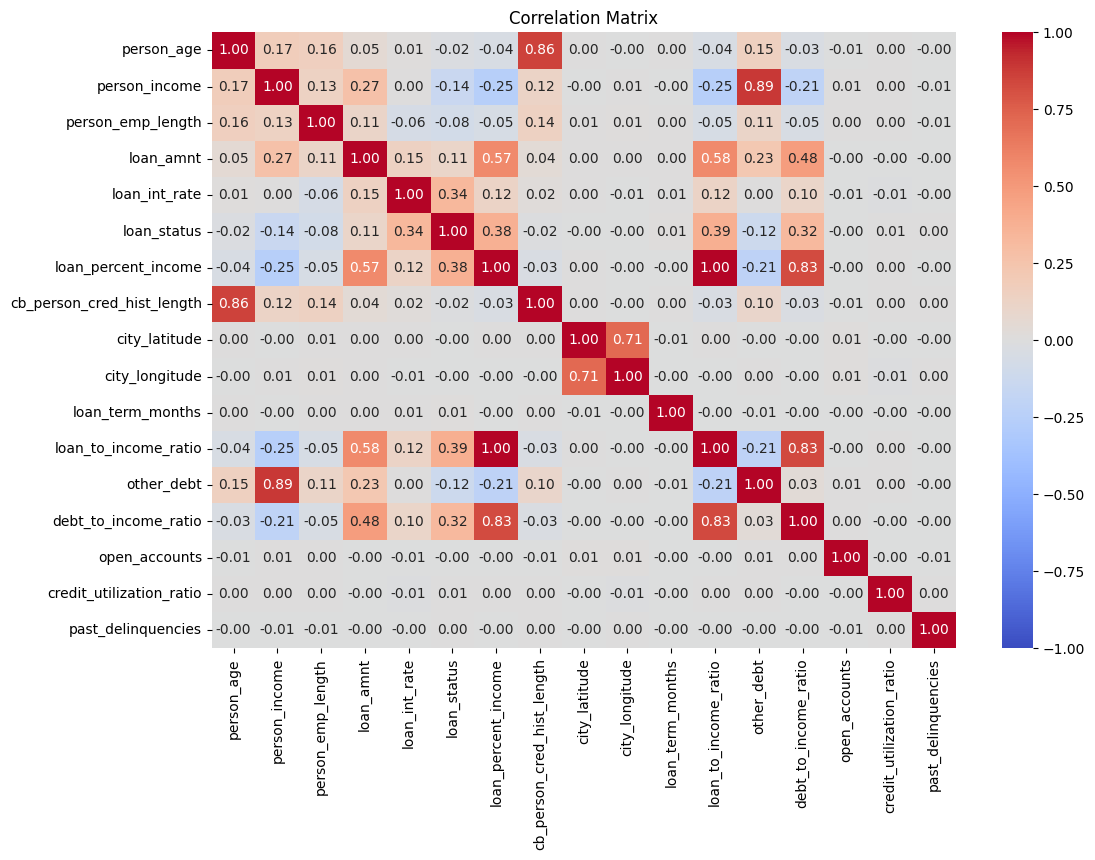


Highly correlated features (>|0.8|):
('cb_person_cred_hist_length', 'person_age', np.float64(0.8591331885974023))
('loan_to_income_ratio', 'loan_percent_income', np.float64(0.9989417203580886))
('other_debt', 'person_income', np.float64(0.8867628098029056))
('debt_to_income_ratio', 'loan_percent_income', np.float64(0.82793366733641))
('debt_to_income_ratio', 'loan_to_income_ratio', np.float64(0.8289018849092759))


In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# Highly correlated pairs
threshold = 0.8
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print("\nHighly correlated features (>|0.8|):")
for pair in high_corr:
    print(pair)

# 7 Target Analysis


===== TARGET DISTRIBUTION =====
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


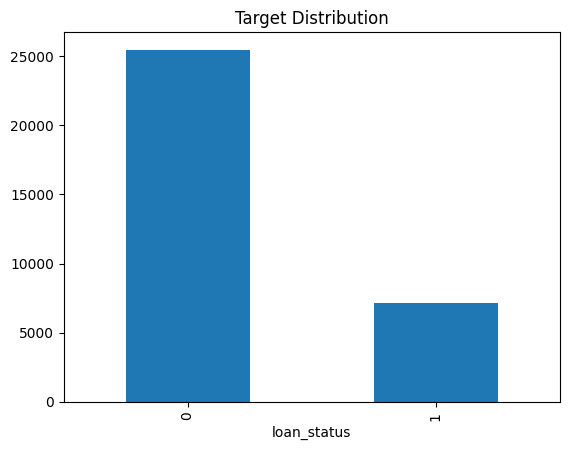

In [14]:
if 'loan_status' in df.columns:
    print("\n===== TARGET DISTRIBUTION =====")
    print(df['loan_status'].value_counts(normalize=True))

    plt.figure()
    df['loan_status'].value_counts().plot(kind='bar')
    plt.title("Target Distribution")
    plt.show()

# 8 Automated Issue Detection

In [15]:
# 1. Columns with missing values
problem_cols = missing_df[missing_df['missing'] > 0]
if len(problem_cols) > 0:
    print("Columns with missing values:")
    print(problem_cols)

# 2. Columns with extreme max values
for col in num_cols:
    if df[col].max() > df[col].quantile(0.99) * 3:
        print(f"Potential extreme outliers in {col}")

# 3. Constant columns
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Constant column: {col}")

# 4. ID-like columns
for col in df.columns:
    if 'id' in col.lower():
        print(f"Possible ID column: {col}")

# 5. High cardinality categorical
for col in cat_cols:
    if df[col].nunique() > 50:
        print(f"High cardinality column: {col}")

Columns with missing values:
                   missing   percent
loan_int_rate         3116  9.563856
person_emp_length      895  2.747000
Potential extreme outliers in person_income
Potential extreme outliers in person_emp_length
Potential extreme outliers in city_longitude
Potential extreme outliers in other_debt
Possible ID column: client_ID
